<a href="https://colab.research.google.com/github/manavdhelia/ML-for-engineers/blob/HW5/hw5_problem3_mnist_knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# k-NN Classification on MNIST with Cross-Validation
## ECE 601 — HW5 Problem 3

Repeat Problem 2 (k-NN with CV-selected k) switching to the MNIST dataset.  
Compare against the one-hidden-layer neural network from HW4 Problem 1(a) in terms of both classification performance and computation time.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load MNIST Dataset

MNIST contains 70,000 grayscale images of handwritten digits (0–9), each 28×28 pixels flattened to 784 features.  
The standard split is 60,000 training samples and 10,000 test samples.

In [2]:
print('Loading MNIST via sklearn (this may take ~30s on first run)...')
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_all = mnist.data.astype(np.float32)
y_all = mnist.target.astype(int)

print(f'Full dataset shape : {X_all.shape}')
print(f'Classes            : {np.unique(y_all)}')

# Standard 60k / 10k split
X_train_full, X_test = X_all[:60000], X_all[60000:]
y_train_full, y_test = y_all[:60000], y_all[60000:]
print(f'Training samples   : {X_train_full.shape}')
print(f'Test samples       : {X_test.shape}')

Loading MNIST via sklearn (this may take ~30s on first run)...
Full dataset shape : (70000, 784)
Classes            : [0 1 2 3 4 5 6 7 8 9]
Training samples   : (60000, 784)
Test samples       : (10000, 784)


## 3. Visualise Sample Images

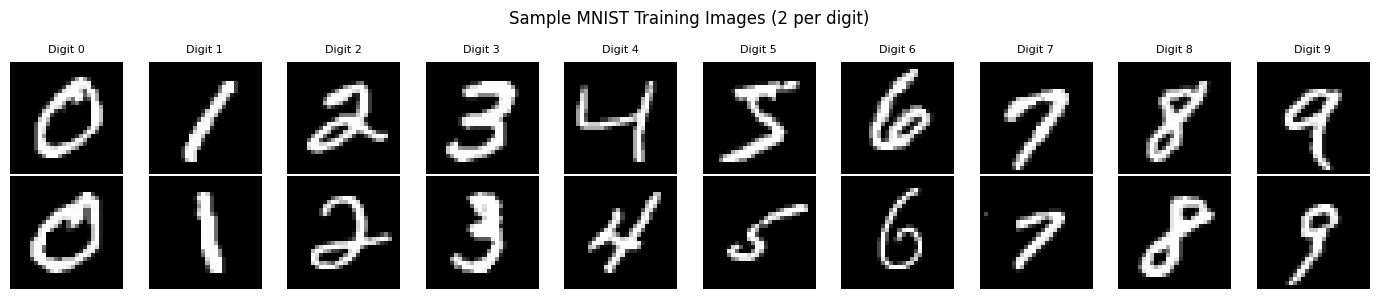

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for digit in range(10):
    idx = np.where(y_train_full == digit)[0][0]
    axes[0, digit].imshow(X_train_full[idx].reshape(28, 28), cmap='gray')
    axes[0, digit].set_title(f'Digit {digit}', fontsize=8)
    axes[0, digit].axis('off')
    idx2 = np.where(y_train_full == digit)[0][1]
    axes[1, digit].imshow(X_train_full[idx2].reshape(28, 28), cmap='gray')
    axes[1, digit].axis('off')
plt.suptitle('Sample MNIST Training Images (2 per digit)', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Preprocessing — StandardScaler

k-NN is a distance-based algorithm. Without scaling, pixels with higher raw intensity variance
would dominate the Euclidean distance computation. StandardScaler zero-centers and unit-normalises
each pixel across the training set.

> **Note:** The scaler is fit **only** on training data, then applied to the test set — this prevents data leakage.

In [4]:
scaler = StandardScaler()
X_train_full_sc = scaler.fit_transform(X_train_full)
X_test_sc       = scaler.transform(X_test)

print('Preprocessing complete.')
print(f'Training set scaled shape : {X_train_full_sc.shape}')
print(f'Test set scaled shape     : {X_test_sc.shape}')

Preprocessing complete.
Training set scaled shape : (60000, 784)
Test set scaled shape     : (10000, 784)


## 5. Subsample for Cross-Validation

Running 5-fold CV over k = 1..15 on all 60,000 × 784 features would take several hours on CPU.
We use a random 10,000-sample subset to select the best k; the final model then trains on the full 60k.

In [5]:
CV_SIZE = 10000
rng = np.random.RandomState(42)
idx = rng.choice(60000, CV_SIZE, replace=False)
X_cv, y_cv = X_train_full_sc[idx], y_train_full[idx]

print(f'CV subset shape     : {X_cv.shape}')
print(f'Class distribution  : {dict(zip(*np.unique(y_cv, return_counts=True)))}')

CV subset shape     : (10000, 784)
Class distribution  : {np.int64(0): np.int64(984), np.int64(1): np.int64(1093), np.int64(2): np.int64(994), np.int64(3): np.int64(1000), np.int64(4): np.int64(980), np.int64(5): np.int64(919), np.int64(6): np.int64(981), np.int64(7): np.int64(1060), np.int64(8): np.int64(979), np.int64(9): np.int64(1010)}


## 6. 5-Fold Cross-Validation to Select Best k

We sweep k = 1 to 15. For each k, 5-fold CV estimates generalisation accuracy on the 10k subset.
The k with the highest mean CV accuracy is selected for the final model.

> **Runtime warning:** This cell takes ~5–15 minutes on Colab CPU. `n_jobs=-1` parallelises across all available cores.

In [6]:
k_range   = range(1, 16)
cv_scores = []

print(f'Running 5-fold CV for k = 1 to {max(k_range)} on {CV_SIZE} samples...')
print(f'{"k":>4}  {"CV Accuracy":>12}  {"Std":>8}')
print('-' * 30)

t_cv_start = time.time()

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1)
    scores = cross_val_score(knn, X_cv, y_cv, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f'{k:>4}  {scores.mean():>12.4f}  {scores.std():>8.4f}')

t_cv_total = time.time() - t_cv_start
best_k = list(k_range)[np.argmax(cv_scores)]

print(f'\nBest k            : {best_k}')
print(f'Best CV Accuracy  : {max(cv_scores):.4f}')
print(f'Total CV time     : {t_cv_total:.1f}s')

Running 5-fold CV for k = 1 to 15 on 10000 samples...
   k   CV Accuracy       Std
------------------------------
   1        0.9103    0.0069
   2        0.8922    0.0038
   3        0.9095    0.0074
   4        0.9087    0.0078
   5        0.9119    0.0062
   6        0.9064    0.0035
   7        0.9097    0.0052
   8        0.9075    0.0059
   9        0.9057    0.0061
  10        0.9055    0.0050
  11        0.9040    0.0046
  12        0.9038    0.0053
  13        0.9022    0.0051
  14        0.9012    0.0050
  15        0.9001    0.0051

Best k            : 5
Best CV Accuracy  : 0.9119
Total CV time     : 88.1s


## 7. Plot CV Accuracy vs k

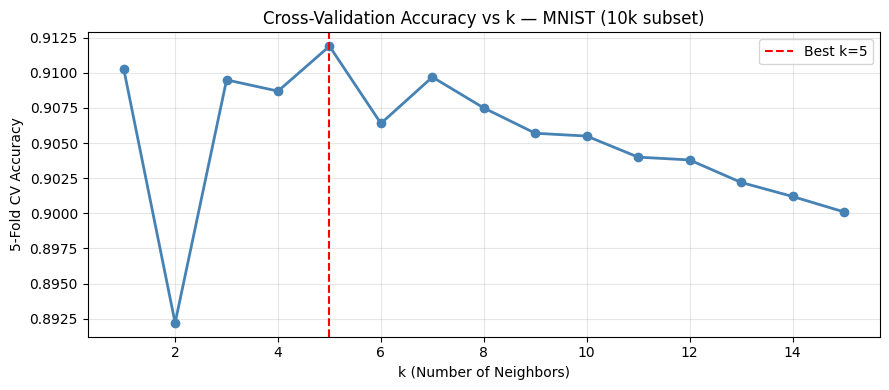

In [7]:
plt.figure(figsize=(9, 4))
plt.plot(list(k_range), cv_scores, marker='o', linewidth=2, color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('5-Fold CV Accuracy')
plt.title('Cross-Validation Accuracy vs k — MNIST (10k subset)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Train Final k-NN on Full 60k Training Set

Since k-NN is a lazy learner, "training" simply stores the data in memory — it takes almost no time.
The computational cost is entirely deferred to prediction time.

In [8]:
print(f'Training final kNN (k={best_k}) on full 60,000 samples...')
t0 = time.time()
knn_final = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', n_jobs=-1)
knn_final.fit(X_train_full_sc, y_train_full)
train_time_knn = time.time() - t0
print(f'Train time (data storage): {train_time_knn:.3f}s')

print(f'\nPredicting on 10,000 test samples...')
print(f'(Each prediction scans all 60k training points — this takes a few minutes)')
t0 = time.time()
y_pred = knn_final.predict(X_test_sc)
pred_time_knn = time.time() - t0
print(f'Predict time : {pred_time_knn:.2f}s')

knn_acc = accuracy_score(y_test, y_pred)
print(f'\nkNN Test Accuracy (k={best_k}): {knn_acc*100:.2f}%')

Training final kNN (k=5) on full 60,000 samples...
Train time (data storage): 0.178s

Predicting on 10,000 test samples...
(Each prediction scans all 60k training points — this takes a few minutes)
Predict time : 43.47s

kNN Test Accuracy (k=5): 94.43%


## 9. Classification Report

In [9]:
print('Classification Report — MNIST kNN:')
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

Classification Report — MNIST kNN:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.99      0.97      1135
           2       0.96      0.93      0.94      1032
           3       0.92      0.95      0.94      1010
           4       0.94      0.94      0.94       982
           5       0.93      0.92      0.93       892
           6       0.96      0.97      0.97       958
           7       0.94      0.92      0.93      1028
           8       0.96      0.90      0.93       974
           9       0.92      0.92      0.92      1009

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



## 10. Confusion Matrix

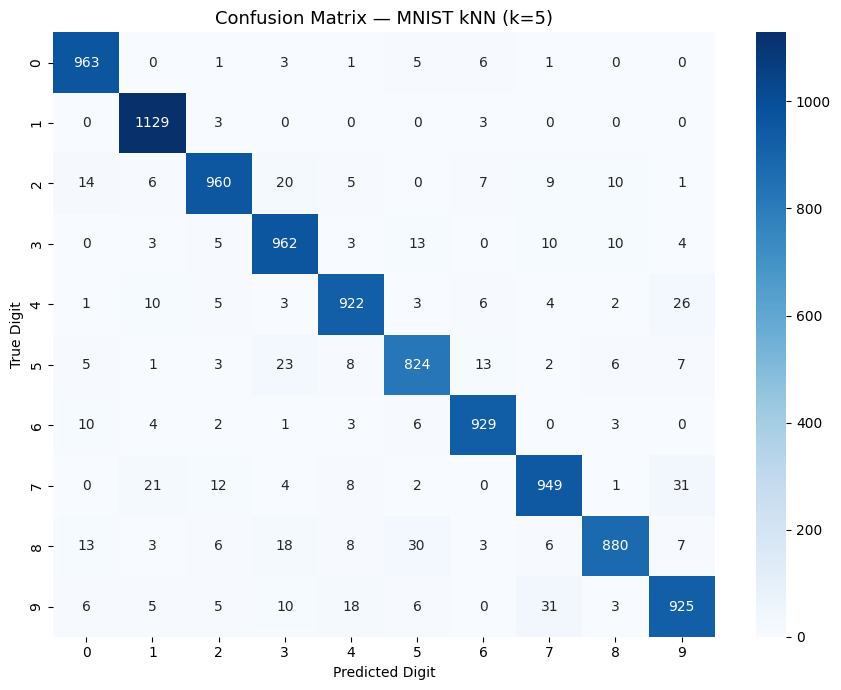

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title(f'Confusion Matrix — MNIST kNN (k={best_k})', fontsize=13)
plt.xlabel('Predicted Digit')
plt.ylabel('True Digit')
plt.tight_layout()
plt.show()

## 11. HW4 Neural Network Reference Results

From HW4 Problem 1(a):
- **Architecture:** Input(784) → Linear(256) → ReLU → Linear(10)
- **Optimizer:** Adam (lr=1e-3, β₁=0.9, β₂=0.999)
- **Training:** 10 epochs, batch size 64, CPU
- **Total parameters:** 203,530
- **Test Accuracy:** 97.84%

In [11]:
# HW4 results — hardcoded from submitted HW4 P1a notebook
nn_acc = 0.9784
nn_per_digit = {
    0: 0.993, 1: 0.991, 2: 0.972, 3: 0.972, 4: 0.990,
    5: 0.959, 6: 0.982, 7: 0.978, 8: 0.976, 9: 0.968
}
print('HW4 Neural Network results loaded.')
print(f'NN Test Accuracy  : {nn_acc*100:.2f}%')
print('Per-digit accuracy:')
for d, a in nn_per_digit.items():
    print(f'  Digit {d}: {a*100:.1f}%')

HW4 Neural Network results loaded.
NN Test Accuracy  : 97.84%
Per-digit accuracy:
  Digit 0: 99.3%
  Digit 1: 99.1%
  Digit 2: 97.2%
  Digit 3: 97.2%
  Digit 4: 99.0%
  Digit 5: 95.9%
  Digit 6: 98.2%
  Digit 7: 97.8%
  Digit 8: 97.6%
  Digit 9: 96.8%


## 12. Accuracy Comparison — kNN vs Neural Network

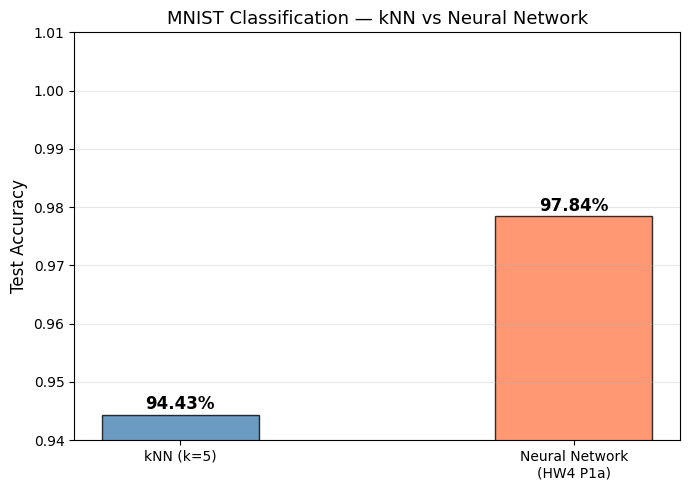

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
models = [f'kNN (k={best_k})', 'Neural Network\n(HW4 P1a)']
accs   = [knn_acc, nn_acc]
colors = ['steelblue', 'coral']
bars   = ax.bar(models, accs, color=colors, alpha=0.8, edgecolor='black', width=0.4)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{acc*100:.2f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_ylim([0.94, 1.01])
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('MNIST Classification — kNN vs Neural Network', fontsize=13)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 13. Per-Digit Accuracy Comparison

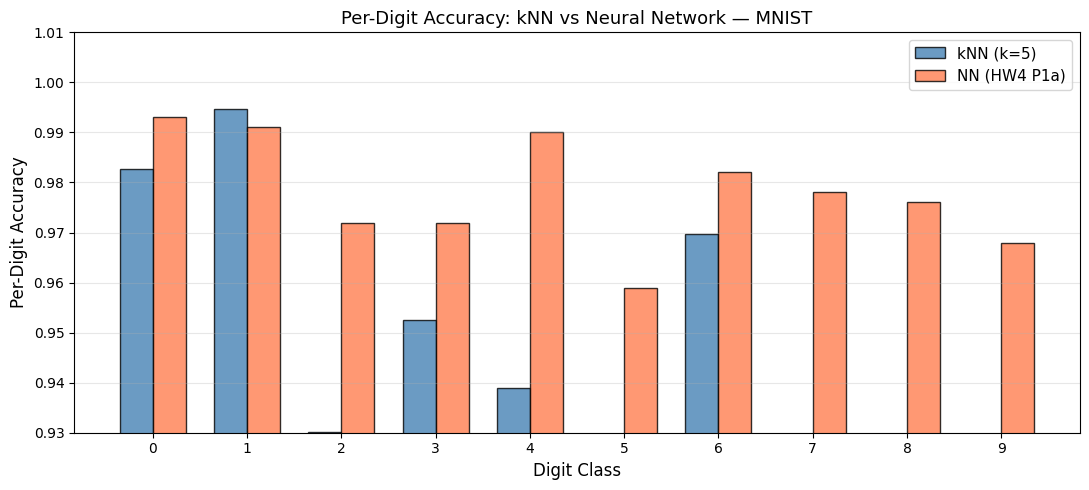


Per-Digit Accuracy Summary:
Digit           kNN   NN (HW4)
------------------------------
0             98.3%      99.3%
1             99.5%      99.1%
2             93.0%      97.2%
3             95.2%      97.2%
4             93.9%      99.0%
5             92.4%      95.9%
6             97.0%      98.2%
7             92.3%      97.8%
8             90.3%      97.6%
9             91.7%      96.8%


In [13]:
knn_per_digit = {}
for d in range(10):
    mask = (y_test == d)
    knn_per_digit[d] = accuracy_score(y_test[mask], y_pred[mask])

fig, ax = plt.subplots(figsize=(11, 5))
x, w = np.arange(10), 0.35
ax.bar(x - w/2, [knn_per_digit[d] for d in range(10)], w,
       label=f'kNN (k={best_k})', color='steelblue', alpha=0.8, edgecolor='black')
ax.bar(x + w/2, [nn_per_digit[d]  for d in range(10)], w,
       label='NN (HW4 P1a)',      color='coral',     alpha=0.8, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in range(10)])
ax.set_xlabel('Digit Class', fontsize=12)
ax.set_ylabel('Per-Digit Accuracy', fontsize=12)
ax.set_title('Per-Digit Accuracy: kNN vs Neural Network — MNIST', fontsize=13)
ax.set_ylim([0.93, 1.01])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nPer-Digit Accuracy Summary:')
print(f'{"Digit":<8} {"kNN":>10} {"NN (HW4)":>10}')
print('-' * 30)
for d in range(10):
    print(f'{d:<8} {knn_per_digit[d]*100:>9.1f}% {nn_per_digit[d]*100:>9.1f}%')

## 14. Computation Time Summary

In [14]:
print('=' * 70)
print('COMPUTATION TIME SUMMARY — MNIST')
print('=' * 70)
print(f'{"Model":<38} {"Train":>12} {"Predict (10k test)":>18}')
print('-' * 70)
print(f'{"kNN (k=" + str(best_k) + ", 60k train, 784 features)":<38} '
      f'{train_time_knn:>10.3f}s {pred_time_knn:>17.2f}s')
print(f'{"NN  (784→256→ReLU→10, Adam, 10 ep)":<38} '
      f'{"~several min":>12} {"<1s":>18}')
print('=' * 70)
print()
print('Key insight:')
print('  kNN train ≈ 0s (just stores data), but prediction is O(n·d) per query.')
print('  With 60k training samples and 784 features, predicting 10k test images')
print('  requires computing 60k × 784 = 47M distances per image → very slow.')
print()
print('  The NN trains slowly via gradient descent (10 epochs × 938 batches),')
print('  but inference is a single forward pass — essentially free.')

COMPUTATION TIME SUMMARY — MNIST
Model                                         Train Predict (10k test)
----------------------------------------------------------------------
kNN (k=5, 60k train, 784 features)          0.178s             43.47s
NN  (784→256→ReLU→10, Adam, 10 ep)     ~several min                <1s

Key insight:
  kNN train ≈ 0s (just stores data), but prediction is O(n·d) per query.
  With 60k training samples and 784 features, predicting 10k test images
  requires computing 60k × 784 = 47M distances per image → very slow.

  The NN trains slowly via gradient descent (10 epochs × 938 batches),
  but inference is a single forward pass — essentially free.


## 15. Final Results Table

In [15]:
print('=' * 55)
print('FINAL RESULTS — MNIST')
print('=' * 55)
print(f'{"Model":<30} {"Test Accuracy":>14}')
print('-' * 55)
print(f'{"kNN (k=" + str(best_k) + ")":<30} {knn_acc*100:>13.2f}%')
print(f'{"Neural Network (HW4 P1a)":<30} {nn_acc*100:>13.2f}%')
print('=' * 55)
print(f'\nGap: NN outperforms kNN by {(nn_acc - knn_acc)*100:.2f} percentage points')

FINAL RESULTS — MNIST
Model                           Test Accuracy
-------------------------------------------------------
kNN (k=5)                              94.43%
Neural Network (HW4 P1a)               97.84%

Gap: NN outperforms kNN by 3.41 percentage points
